In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

In [114]:
df = pd.read_csv("crawled_data.csv")
df.head(20)

,Product:,Sale Date:,Category:,Quantity:,Total Price:,Total Profit:,Payment Type:,Customer Details:
0,White Tie and Shirt Set,01-01-2025,Men — Shirts,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...
1,Floral Embroidered Kaftan,2025-01-01,Children — Girls Clothing,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...
2,Black Loose Fit Jeans,2025-01-02,Men — Jeans,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...
3,Dark Wash Straight Fit Jeans,2025-01-02,Men — Jeans,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...
4,Rose Print Prom Dress,2025-01-02,Children — Girls Clothing,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...
5,Orange/Navy Shorts Three Pack,2025-01-02,Children — Girls Clothing,2,EUR 33.00,EUR 16.83,Credit Card,Location Kerry\nCust ID: 7822\nGender: Female\...
6,Dark Wash Straight Fit Jeans,2025-01-03,Men — Jeans,-1,EUR 33.00,EUR 13.20,Debit Card,Customer ID: 18791\nCity: Dublin\nGender: Male...
7,Dawson Trolley,2025-01-03,Homeware — Design,1,€57.00,€22.80,Credit Card,Customer ID: 12619\nCity: Kildare\nGender: Fem...
8,Light Blue Ditsy Slub Dress,2025-01-03,Women — Dresses,1,20.25,9.00,Credit Card,Cust ID: 17834\nLocation: Laois\nGender: Male\...
9,Black Signature Point Court Shoes,03-01-2025,Men — Shoes,2,88.00,39.60,Debit Card,Cust ID: 1331\nLocation Dublin\nGender: Female...


# Preprocessing Data

## Remove header postfix

In [115]:
print("Before:", df.columns)
df.columns = df.columns.str.rstrip(':')
print("After:", df.columns)

Before: Index(['Product:', 'Sale Date:', 'Category:', 'Quantity:', 'Total Price:',
       'Total Profit:', 'Payment Type:', 'Customer Details:'],
      dtype='str')
After: Index(['Product', 'Sale Date', 'Category', 'Quantity', 'Total Price',
       'Total Profit', 'Payment Type', 'Customer Details'],
      dtype='str')


## Sale Dates

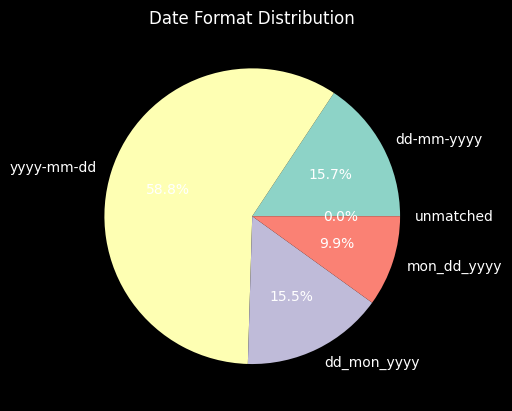

In [116]:
import functools
import operator

patterns = {
    "dd-mm-yyyy": r"^(0[1-9]|[12][0-9]|3[01])-(0[1-9]|1[0-2])-\d{4}$",
    "yyyy-mm-dd": r"^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12][0-9]|3[01])$",
    "dd_mon_yyyy": r"^(0?[1-9]|[12][0-9]|3[01])\s(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s\d{4}$",
    "mon_dd_yyyy": r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s(0?[1-9]|[12][0-9]|3[01]),\s\d{4}$"
}

total = len(df)

# build masks
masks = {
    name: df['Sale Date'].str.match(pattern, na=False)
    for name, pattern in patterns.items()
}

# percentages for known formats
percentages = {
    name: mask.mean() * 100
    for name, mask in masks.items()
}

# unmatched
any_match = functools.reduce(operator.or_, masks.values())
percentages["unmatched"] = (~any_match).mean() * 100

labels = percentages.keys()
sizes = percentages.values()

plt.figure()
plt.pie(sizes, labels=list(labels), autopct='%1.1f%%')
plt.title("Date Format Distribution")
plt.show()

In [117]:
df['Sale Date'] = pd.to_datetime(df['Sale Date'], errors='raise', format='mixed')
df.head(5)

,Product,Sale Date,Category,Quantity,Total Price,Total Profit,Payment Type,Customer Details
0,White Tie and Shirt Set,2025-01-01,Men — Shirts,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...
1,Floral Embroidered Kaftan,2025-01-01,Children — Girls Clothing,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...
2,Black Loose Fit Jeans,2025-01-02,Men — Jeans,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...
3,Dark Wash Straight Fit Jeans,2025-01-02,Men — Jeans,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...
4,Rose Print Prom Dress,2025-01-02,Children — Girls Clothing,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...


## Category Column

In [118]:
pattern = r'\s*[—]\s*'

In [119]:
# Mask for rows that **match** the pattern
mask_match = df['Category'].str.contains(pattern, regex=True, na=False)

# Number of rows that **do NOT match**
num_unmatched = (~mask_match).sum()

print(f"Number of unmatched rows: {num_unmatched}")

Number of unmatched rows: 0


In [120]:
df[['Category_main', 'Category_sub']] = df['Category'].str.split(pattern, n=1, expand=True)
df['Category_main'] = df['Category_main'].str.strip()
df['Category_sub'] = df['Category_sub'].str.strip()

df.drop('Category', axis=1, inplace=True)
df.head(5)

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Customer Details,Category_main,Category_sub
0,White Tie and Shirt Set,2025-01-01,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...,Men,Shirts
1,Floral Embroidered Kaftan,2025-01-01,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...,Children,Girls Clothing
2,Black Loose Fit Jeans,2025-01-02,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...,Men,Jeans
3,Dark Wash Straight Fit Jeans,2025-01-02,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...,Men,Jeans
4,Rose Print Prom Dress,2025-01-02,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...,Children,Girls Clothing


## Quantity Column

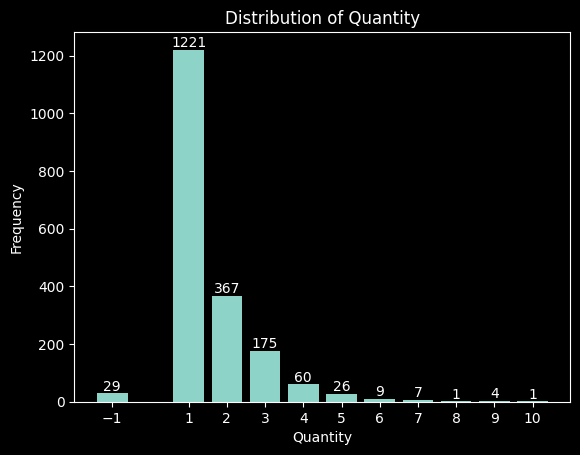

In [121]:
import matplotlib.pyplot as plt

counts = df['Quantity'].value_counts().sort_index()

bars = plt.bar(counts.index, counts.values)

plt.xlabel("Quantity")
plt.xticks(counts.index)
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")

# add count labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.show()

## Total Price/Total Profit Column

In [122]:
df.head()

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Customer Details,Category_main,Category_sub
0,White Tie and Shirt Set,2025-01-01,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...,Men,Shirts
1,Floral Embroidered Kaftan,2025-01-01,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...,Children,Girls Clothing
2,Black Loose Fit Jeans,2025-01-02,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...,Men,Jeans
3,Dark Wash Straight Fit Jeans,2025-01-02,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...,Men,Jeans
4,Rose Print Prom Dress,2025-01-02,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...,Children,Girls Clothing


In [123]:
pattern = r'(€|EUR)'

df['Total Price'] = df['Total Price'].str.replace(pattern, '', regex=True).str.strip().astype(float)
df['Total Profit'] = df['Total Profit'].str.replace(pattern, '', regex=True).str.strip().astype(float)
df.head(20)

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Customer Details,Category_main,Category_sub
0,White Tie and Shirt Set,2025-01-01,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...,Men,Shirts
1,Floral Embroidered Kaftan,2025-01-01,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...,Children,Girls Clothing
2,Black Loose Fit Jeans,2025-01-02,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...,Men,Jeans
3,Dark Wash Straight Fit Jeans,2025-01-02,1,33.00,13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...,Men,Jeans
4,Rose Print Prom Dress,2025-01-02,1,37.00,18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...,Children,Girls Clothing
5,Orange/Navy Shorts Three Pack,2025-01-02,2,33.00,16.83,Credit Card,Location Kerry\nCust ID: 7822\nGender: Female\...,Children,Girls Clothing
6,Dark Wash Straight Fit Jeans,2025-01-03,-1,33.00,13.20,Debit Card,Customer ID: 18791\nCity: Dublin\nGender: Male...,Men,Jeans
7,Dawson Trolley,2025-01-03,1,57.00,22.80,Credit Card,Customer ID: 12619\nCity: Kildare\nGender: Fem...,Homeware,Design
8,Light Blue Ditsy Slub Dress,2025-01-03,1,20.25,9.00,Credit Card,Cust ID: 17834\nLocation: Laois\nGender: Male\...,Women,Dresses
9,Black Signature Point Court Shoes,2025-03-01,2,88.00,39.60,Debit Card,Cust ID: 1331\nLocation Dublin\nGender: Female...,Men,Shoes


## Payment Type Column

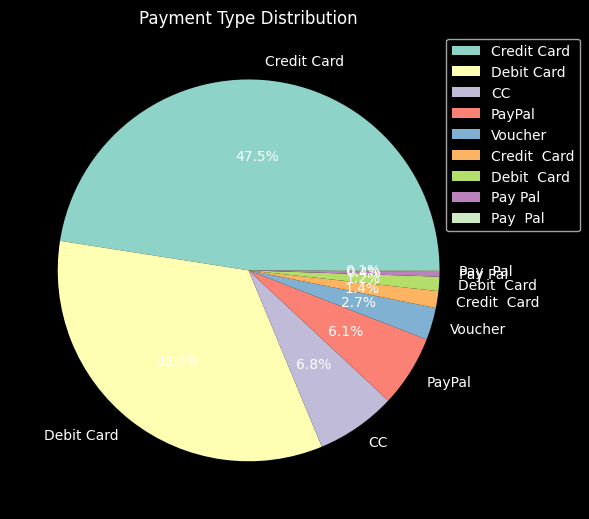

In [124]:
def visualize_payment_type_count(_df: pd.DataFrame):
    payment_types = _df['Payment Type'].value_counts()

    payment_types.plot.pie(
        autopct='%1.1f%%',
        figsize=(6,6),
        ylabel=''
    )

    plt.legend(payment_types.index, loc="upper left", bbox_to_anchor=(0.9, 1))

    plt.title("Payment Type Distribution")
    plt.tight_layout()

    plt.show()

visualize_payment_type_count(df)

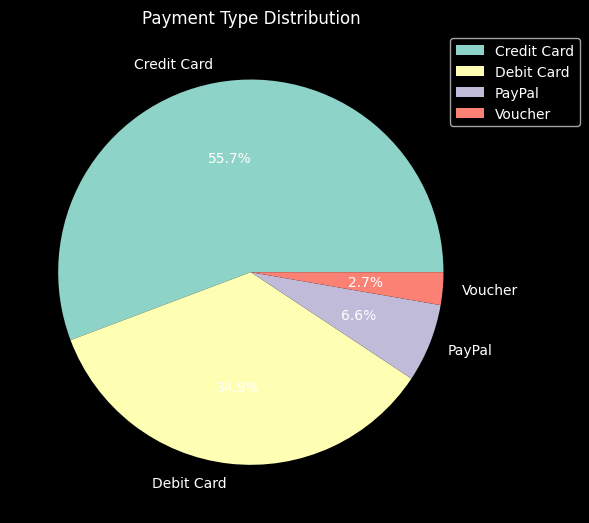

In [125]:
df['Payment Type'] = df['Payment Type'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['Payment Type'] = df['Payment Type'].str.replace({"Pay Pal": "PayPal", "CC": "Credit Card"})

visualize_payment_type_count(df)

## Customer Detail Column

In [126]:
df["Customer Details"].head()

0    Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...
1    Customer ID: 10753\nLocation Laois\nGender: F\...
2    ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...
3    Age Range: 35-44\nGender: Male\nLocation: Lout...
4    ID: 12591\nCity: Dublin\nGender: Female\nAge G...
Name: Customer Details, dtype: str

In [127]:
def parse_customer_info_strict(info_str):
    # Define exception patterns and target columns inside the method
    exception_patterns = {
        r'^ID\s+(.+)$': 'ID',
        r'^Location\s+(.+)$': 'Location'
    }

    data_dict = {}
    for line in info_str.split('\n'):
        line = line.strip()
        if not line:
            continue

        matched = False
        # Check exceptions
        for pattern, col_name in exception_patterns.items():
            match = re.match(pattern, line)
            if match:
                data_dict[col_name] = match.group(1).strip()
                matched = True
                break
        if matched:
            continue

        # All other lines must be key: value
        if ':' in line:
            key, value = line.split(':', 1)
            data_dict[key.strip()] = value.strip()
        else:
            # Neither exception nor key:value → raise error
            raise ValueError(f"Invalid line format: '{line}'")


    return data_dict

customer_detail_df = (
    df['Customer Details']
    .apply(parse_customer_info_strict)
    .apply(pd.Series)
)

customer_detail_df.head(30)


,Cust ID,From,Gender,Age Range,Customer ID,Location,Age Group,ID,Age Category,City,Age
0,7097,Dublin,Female,25-34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,F,NaN,10753,Laois,35—44,NaN,NaN,NaN,NaN
2,NaN,NaN,Male,NaN,NaN,NaN,NaN,17356,55—64,Mayo,NaN
3,NaN,NaN,Male,35-44,9750,Louth,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Female,NaN,NaN,NaN,35-44,12591,NaN,Dublin,NaN
5,7822,NaN,Female,NaN,NaN,Kerry,45-54,NaN,NaN,NaN,NaN
6,NaN,NaN,Male,25-34,18791,NaN,NaN,NaN,NaN,Dublin,NaN
7,NaN,NaN,Female,18-24,12619,NaN,NaN,NaN,NaN,Kildare,NaN
8,17834,NaN,Male,NaN,NaN,Laois,NaN,NaN,35-44,NaN,NaN
9,1331,NaN,Female,25-34,NaN,Dublin,NaN,NaN,NaN,NaN,NaN


### Customer ID Column
Might be derived from one of there variants: `Cust ID`, `Customer ID` and `ID`

One of those columns should have value while the other 2 columns are NaN

In [128]:
cols = ["Cust ID", "Customer ID", "ID"]

print("Number of data with duplicated customer ID value: ", (customer_detail_df[cols].notna().sum(axis=1) != 1).sum())

Number of data with duplicated customer ID value:  0


In [129]:
customer_detail_df["Customer ID"] = customer_detail_df[cols].bfill(axis=1).iloc[:, 0]
customer_detail_df = customer_detail_df.drop(["Cust ID", "ID"], axis=1)

customer_detail_df.sample()

,From,Gender,Age Range,Customer ID,Location,Age Group,Age Category,City,Age
553,NaN,F,NaN,11222,Cork,NaN,35—44,NaN,NaN


In [130]:
print("Number of data with duplicated customer ID value: ", customer_detail_df["Customer ID"].isna().sum())

Number of data with duplicated customer ID value:  0


### Location Column

In [131]:
cols = ["From", "Location", "City"]
print("Number of data with duplicated location value: ", (customer_detail_df[cols].notna().sum(axis=1) != 1).sum())

Number of data with duplicated location value:  0


In [132]:
customer_detail_df["Location"] = customer_detail_df[cols].bfill(axis=1).iloc[:, 0]
customer_detail_df = customer_detail_df.drop(["From", "City"], axis=1)

customer_detail_df.head()

,Gender,Age Range,Customer ID,Location,Age Group,Age Category,Age
0,Female,25-34,7097,Dublin,NaN,NaN,NaN
1,F,NaN,10753,Laois,35—44,NaN,NaN
2,Male,NaN,17356,Mayo,NaN,55—64,NaN
3,Male,35-44,9750,Louth,NaN,NaN,NaN
4,Female,NaN,12591,Dublin,35-44,NaN,NaN


### Age Group Column

In [133]:
cols = ["Age Range", "Age Group", "Age Category", "Age"]
print("Number of data with duplicated age group value: ", (customer_detail_df[cols].notna().sum(axis=1) != 1).sum())

Number of data with duplicated age group value:  0


In [134]:
customer_detail_df["Age Group"] = customer_detail_df[cols].bfill(axis=1).iloc[:, 0]
customer_detail_df = customer_detail_df.drop(["Age Range", "Age Category", "Age"], axis=1)

customer_detail_df.sample(5)

,Gender,Customer ID,Location,Age Group
1447,M,8837,Wexford,18–24
350,Male,2181,Dublin,None
1235,Female,5169,Dublin,45-54
835,Male,8447,Clare,18–24
1674,Female,9803,Kildare,18-24


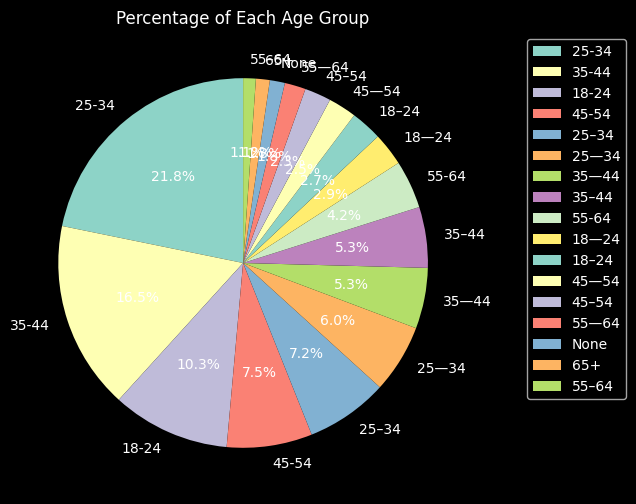

In [135]:
def visualise_age_group(_df: pd.DataFrame):
    # Count the occurrences of each Age Group
    age_counts = _df['Age Group'].value_counts()

    # Plot pie chart
    plt.figure(figsize=(6,6))
    plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)

    plt.legend(age_counts.index, title="Age Groups", loc="best")
    plt.legend(age_counts.index, loc="upper left", bbox_to_anchor=(1.1, 1))

    plt.title('Percentage of Each Age Group')
    plt.show()

visualise_age_group(customer_detail_df)

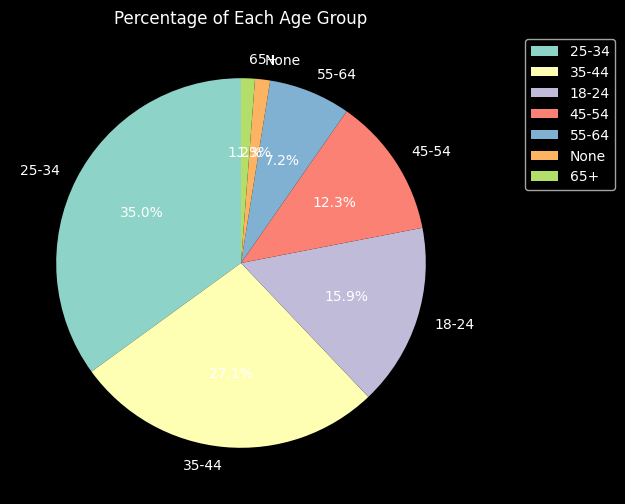

In [136]:
pattern = r'\s*[\u2012\u2013\u2014\u2015\-\u2212]+\s*'
customer_detail_df['Age Group'] = customer_detail_df['Age Group'].str.replace(pattern, '-', regex=True).str.strip()

visualise_age_group(customer_detail_df)

### Gender Column

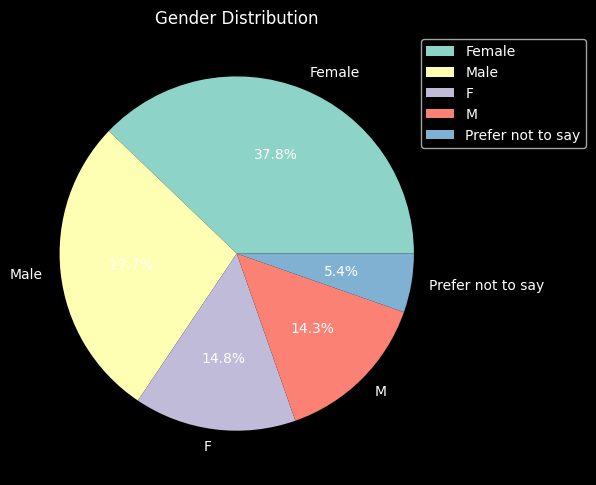

In [137]:
def visualise_gender_count(_df: pd.DataFrame):
    payment_types = _df['Gender'].value_counts()

    payment_types.plot.pie(
        autopct='%1.1f%%',
        figsize=(6,6),
        ylabel=''
    )

    plt.legend(payment_types.index, loc="upper left", bbox_to_anchor=(0.9, 1))

    plt.title("Gender Distribution")
    plt.tight_layout()

    plt.show()

visualise_gender_count(customer_detail_df)

In [138]:
mapping_rule = {
    "F": "Female",
    "M": "Male",
    "Prefer not to say": np.nan,
}

customer_detail_df["Gender"] = customer_detail_df['Gender'].replace(mapping_rule)

customer_detail_df.sample(10)


,Gender,Customer ID,Location,Age Group
169,Male,14850,Westmeath,35-44
1094,Male,8603,Tipperary,45-54
1201,Female,15403,Dublin,25-34
794,Male,3708,Galway,35-44
942,Female,2484,Laois,18-24
1157,Male,9181,Galway,25-34
973,Male,1341,Dublin,25-34
1010,Male,18447,Wicklow,35-44
1131,Male,3894,Wicklow,25-34
1117,Male,11912,Wicklow,18-24


### Integrate preprocessed customer detail into main data

In [139]:
df = df.join(customer_detail_df, how="inner")

df.drop(["Customer Details"], axis=1, inplace=True)

df.sample(10)

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Category_main,Category_sub,Gender,Customer ID,Location,Age Group
45,Double Wall Mug,2025-04-03,1,12.5,5.00,Credit Card,Homeware,Design,Female,13066,Meath,25-34
1142,Black Skinny Fit Ultra Flex Jeans,2025-08-02,1,33.0,13.20,Credit Card,Men,Jeans,Female,12591,Dublin,35-44
580,Hawaiian Print Sun Safe Two Piece,2025-12-04,2,35.0,17.85,Credit Card,Children,Girls Clothing,Male,6466,Dublin,25-34
1797,Navy/White Long Sleeve Gingham Cheque Shirt,2025-12-07,2,58.0,22.04,Credit Card,Men,Shirts,Female,7059,Dublin,35-44
143,Grey Marl Panda Face Crew,2025-01-12,3,34.5,17.59,Credit Card,Children,Boys Clothing,Male,14681,Dublin,65+
175,Black Loose Fit Jeans,2025-01-18,1,29.0,11.60,Credit Card,Men,Jeans,Female,6033,Dublin,45-54
1228,Multi Llama Vests Three Pack,2025-08-18,1,17.5,8.93,Credit Card,Children,Girls Clothing,Female,7834,Kildare,35-44
1060,Mid Blue Slim Fit Ultra Flex Jeans,2025-07-17,1,48.0,19.20,Debit Card,Men,Jeans,Female,9012,Tipperary,35-44
293,Mid Blue Straight Fit Jeans,2025-02-13,1,38.0,15.20,Debit Card,Men,Jeans,NaN,4603,Kerry,45-54
362,White Colour Block T-Shirt,2025-02-25,2,45.0,22.95,Debit Card,Children,Boys Clothing,Male,3819,Cork,25-34


# Analysis

## Revenue Trend

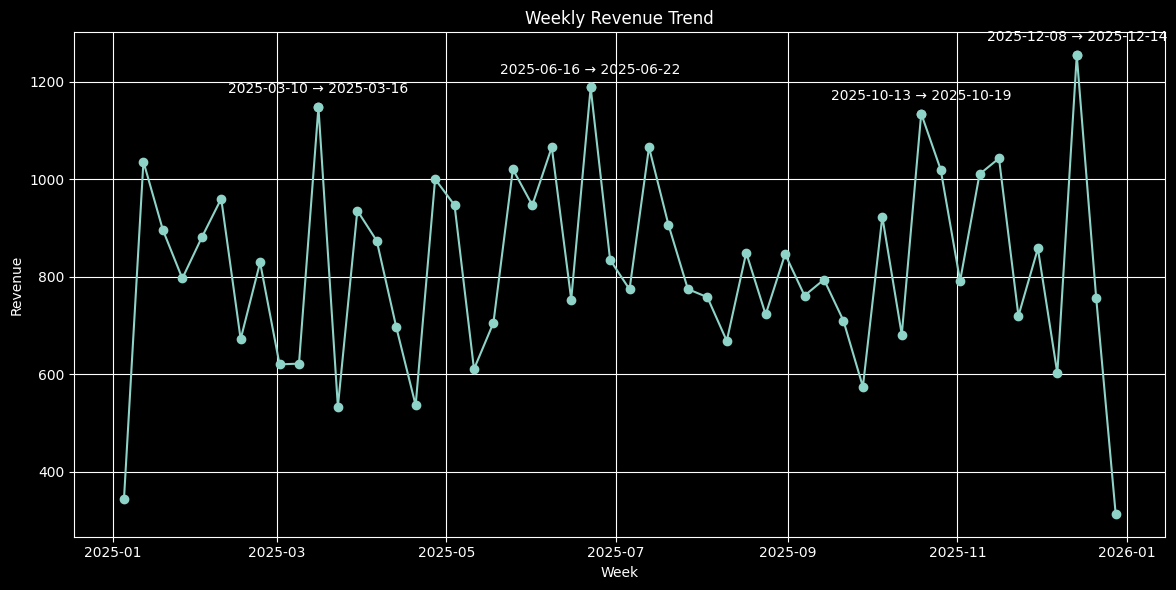

In [140]:
# Create a working copy so the original dataframe is not modified
df_weekly = df.copy()

# Convert Sale Date to datetime in the copy
df_weekly['Sale Date'] = pd.to_datetime(df_weekly['Sale Date'])

# Set index for resampling
df_weekly = df_weekly.set_index('Sale Date')

# Aggregate revenue by week
weekly_revenue = df_weekly['Total Profit'].resample('W').sum()

# Identify top 4 peak weeks
top4 = weekly_revenue.nlargest(4)

# Plot weekly revenue trend
plt.figure(figsize=(12,6))
plt.plot(weekly_revenue.index, weekly_revenue.values, marker='o')

# Highlight peaks
plt.scatter(top4.index, top4.values, zorder=3, label="Top 4 Peaks")

# Annotate peaks with week duration
for week_end, revenue in top4.items():
    week_start = week_end - pd.Timedelta(days=6)
    label = f"{week_start.date()} → {week_end.date()}"

    plt.annotate(
        label,
        (week_end, revenue),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )


plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.grid(True)

plt.tight_layout()
plt.show()

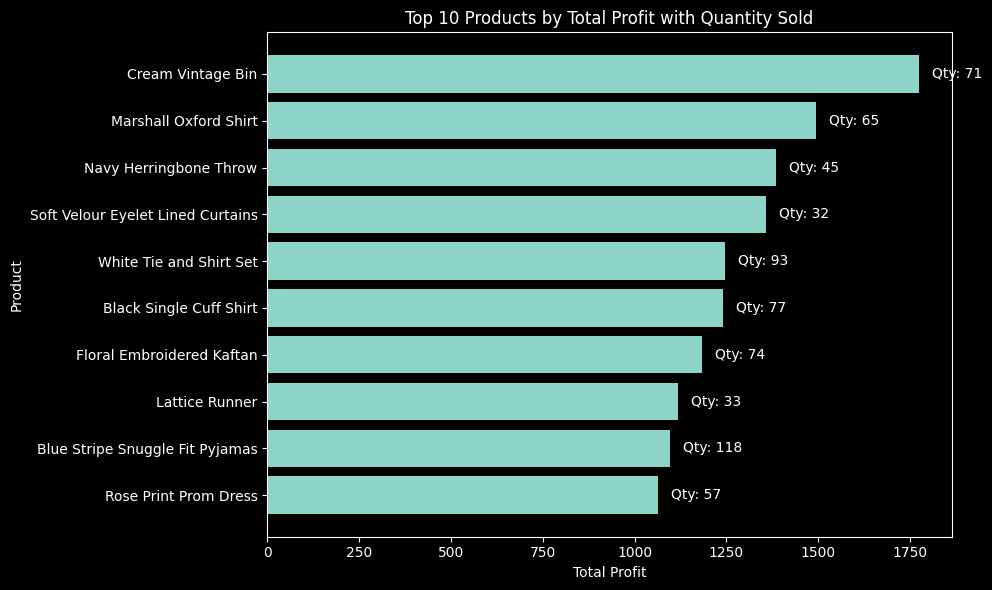

In [141]:
# Aggregate total profit and total quantity by Product
summary = df.groupby('Product').agg({
    'Total Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Get top 10 products by Total Profit
top10 = summary.sort_values(by='Total Profit', ascending=False).head(10)

# Plot horizontal bars for Total Profit
plt.figure(figsize=(10, 6))
bars = plt.barh(top10['Product'], top10['Total Profit'])

# Invert y-axis so highest profit is on top
plt.gca().invert_yaxis()

# Annotate quantity sold next to each bar
for bar, qty in zip(bars, top10['Quantity']):
    plt.text(
        bar.get_width() + 0.02 * top10['Total Profit'].max(),  # small offset
        bar.get_y() + bar.get_height()/2,
        f'Qty: {int(qty)}',
        va='center'
    )

plt.xlabel('Total Profit')
plt.ylabel('Product')
plt.title('Top 10 Products by Total Profit with Quantity Sold')
plt.tight_layout()
plt.show()

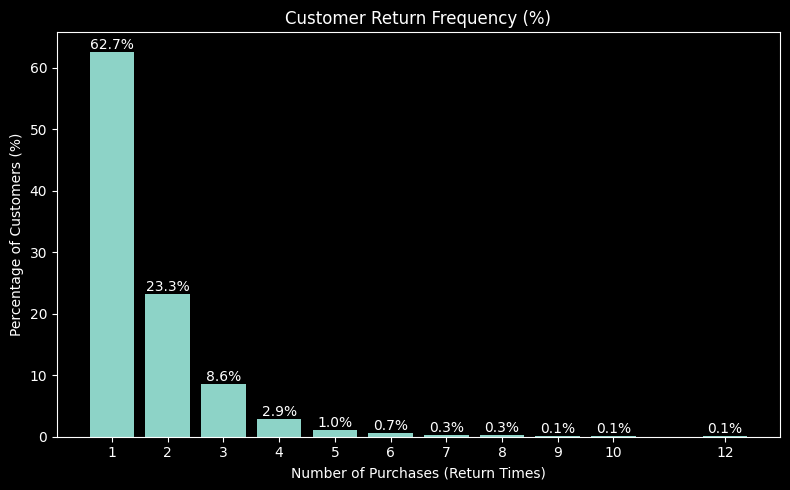

In [142]:
# Number of purchases per customer
customer_purchases = df.groupby('Customer ID').size()

# Distribution of purchase counts
return_distribution = customer_purchases.value_counts().sort_index()

# Convert to percentage
percentage_distribution = (return_distribution / return_distribution.sum()) * 100

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(percentage_distribution.index, percentage_distribution.values)

plt.xlabel('Number of Purchases (Return Times)')
plt.ylabel('Percentage of Customers (%)')
plt.title('Customer Return Frequency (%)')

plt.xticks(percentage_distribution.index)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

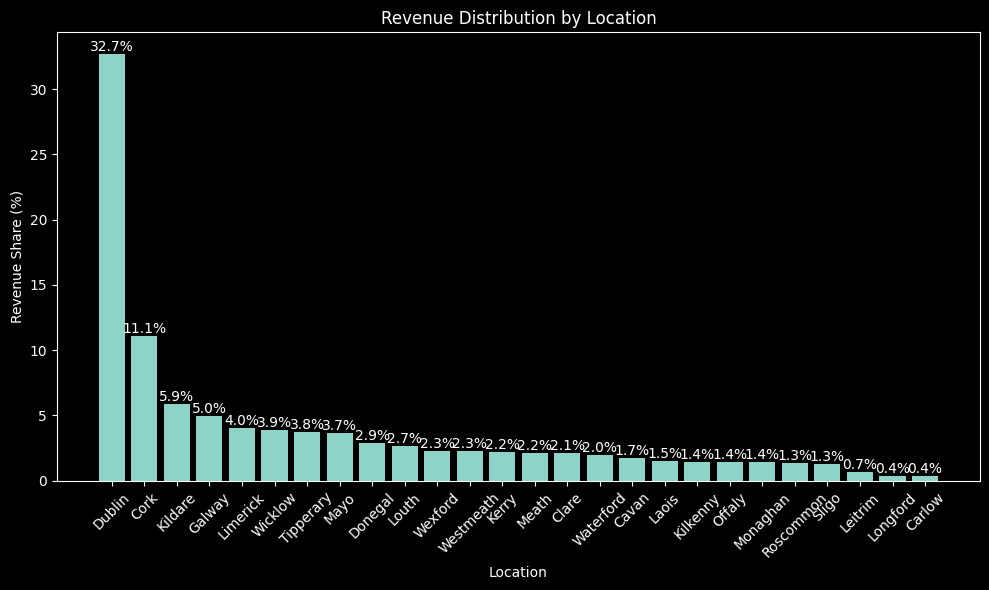

In [143]:
# Total revenue by location
revenue_location = df.groupby('Location')['Total Price'].sum()

# Convert to percentage of total revenue
revenue_percentage = (revenue_location / revenue_location.sum()) * 100

# Sort for better visualization
revenue_percentage = revenue_percentage.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(revenue_percentage.index, revenue_percentage.values)

plt.xlabel('Location')
plt.ylabel('Revenue Share (%)')
plt.title('Revenue Distribution by Location')
plt.xticks(rotation=45)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

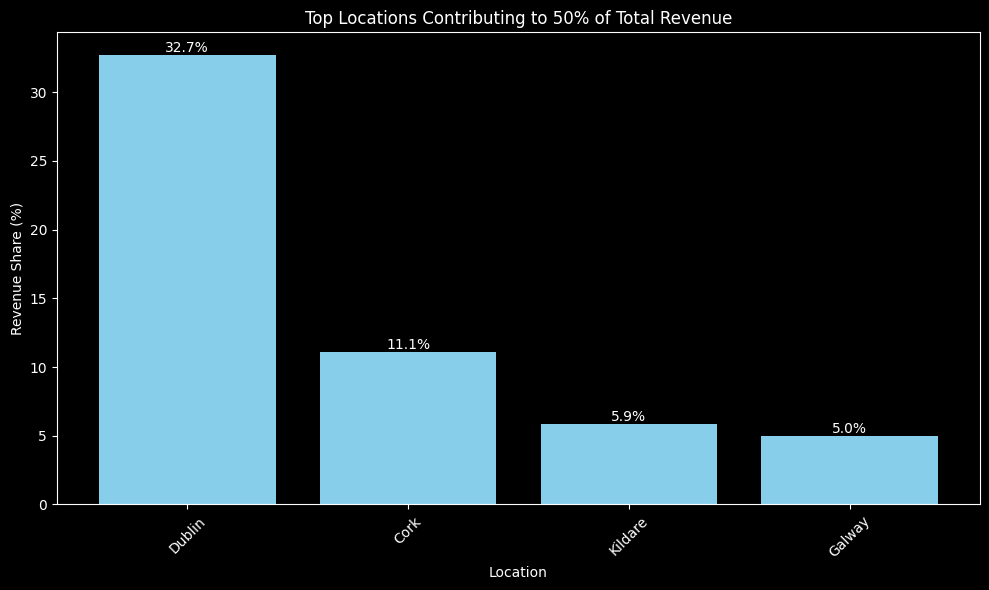

In [144]:
import matplotlib.pyplot as plt

# Compute revenue per location
revenue_location = df.groupby('Location')['Total Price'].sum().sort_values(ascending=False)

# Convert to percentage of total revenue
revenue_percentage = (revenue_location / revenue_location.sum()) * 100

# Cumulative percentage
cumulative_percentage = revenue_percentage.cumsum()

# Select top locations contributing to ~50% of revenue
top_locations = revenue_percentage[cumulative_percentage <= 50]
# Include the location that crosses 50%
top_locations = revenue_percentage.iloc[:len(top_locations)+1]

# Visualize top locations
plt.figure(figsize=(10,6))
bars = plt.bar(top_locations.index, top_locations.values, color='skyblue')
plt.xlabel('Location')
plt.ylabel('Revenue Share (%)')
plt.title('Top Locations Contributing to 50% of Total Revenue')
plt.xticks(rotation=45)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Filter the dataframe for top locations for further analysis
top_df = df[df['Location'].isin(top_locations.index)]

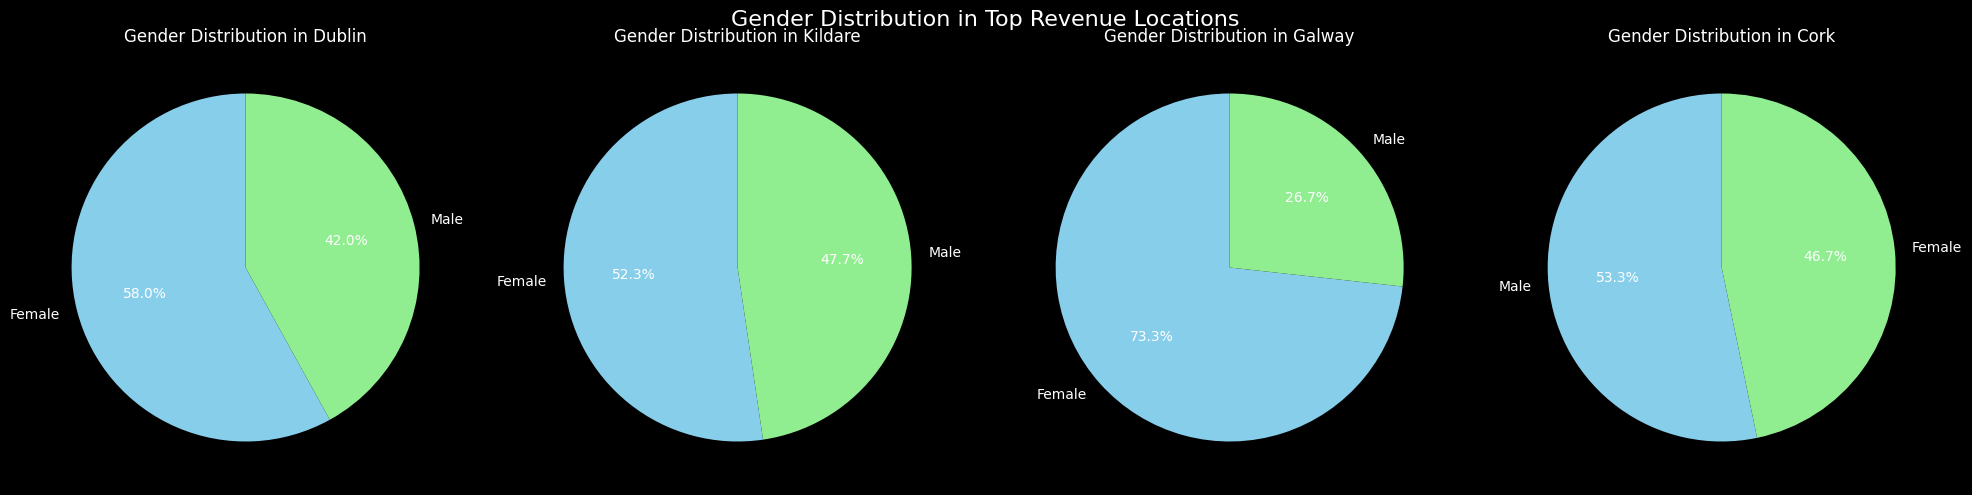

In [145]:
import matplotlib.pyplot as plt

# Step 1: Top locations already selected
# top_df contains only customers from top revenue locations

# Get the list of top locations
locations = top_df['Location'].unique()

# Set up subplots: one pie chart per city
n = len(locations)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

# If only one location, axes is not a list
if n == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    city_data = top_df[top_df['Location'] == loc]
    gender_dist = city_data['Gender'].value_counts()

    ax.pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%', startangle=90, colors=['skyblue','lightgreen'])
    ax.set_title(f'Gender Distribution in {loc}')

plt.suptitle('Gender Distribution in Top Revenue Locations', fontsize=16)
plt.tight_layout()
plt.show()

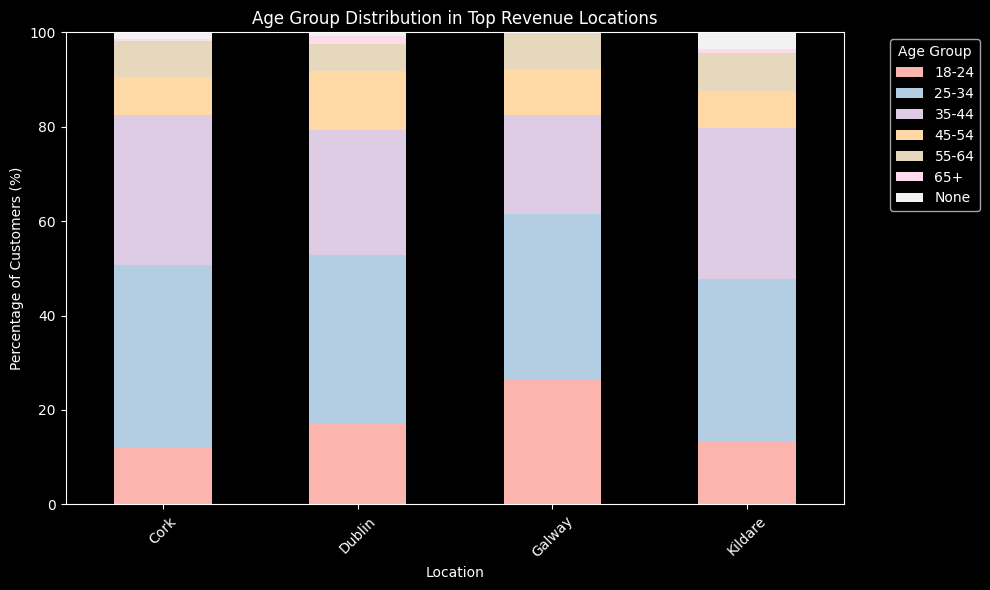

In [146]:
# Count of customers per Age Group per Location
age_location = top_df.groupby(['Location', 'Age Group']).size().unstack(fill_value=0)

# Convert counts to percentages per city
age_location_pct = age_location.div(age_location.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
age_location_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Pastel1')

plt.ylabel('Percentage of Customers (%)')
plt.xlabel('Location')
plt.title('Age Group Distribution in Top Revenue Locations')
plt.xticks(rotation=45)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()